# Final Project - Reinforcements Learning

Maor Hornstein, 300278520
<br>

<img src="https://play-lh.googleusercontent.com/e_oKlKPISbgdzut1H9opevS7-LTB8-8lsmpCdMkhlnqFenZhpjxbLmx7l158-xQQCIY">

# Introduction

TODO

# Installs

Please enable this cell when running on colab environment:

In [72]:
'''
%%capture
!sudo apt-get update
!sudo apt-get install -y xvfb ffmpeg freeglut3-dev
!pip install 'imageio==2.4.0'
!pip install gym
!pip install pygame
!apt-get install python-opengl -y
!apt install xvfb -y
!pip install pyvirtualdisplay
!pip install piglet
!pip install gym
!apt-get install python-opengl -y
!apt install xvfb -y
!pip install gym_sokoban
!git clone https://github.com/avivg7/sokoban-so.git
!unzip /content/sokoban-so/Compress.zip
'''

"\n%%capture\n!sudo apt-get update\n!sudo apt-get install -y xvfb ffmpeg freeglut3-dev\n!pip install 'imageio==2.4.0'\n!pip install gym\n!pip install pygame\n!apt-get install python-opengl -y\n!apt install xvfb -y\n!pip install pyvirtualdisplay\n!pip install piglet\n!pip install gym\n!apt-get install python-opengl -y\n!apt install xvfb -y\n!pip install gym_sokoban\n!git clone https://github.com/avivg7/sokoban-so.git\n!unzip /content/sokoban-so/Compress.zip\n"

# Imports

In [73]:
import os
import sys
if os.name == 'nt': # this means we run locally on windows
    sys.path.append('../')

In [74]:
import numpy as np
import gym
from gym import logger as gymlogger
from gym.utils import seeding
from gym import error, spaces, utils
gymlogger.set_level(40) # error only
from soko_pap import *
import glob
import io
import base64
import os
import random
import matplotlib.pyplot as plt
%matplotlib inline
import math
import glob
from pyvirtualdisplay import Display
from IPython.display import HTML
from IPython import display as ipythondisplay
import pygame
import pyvirtualdisplay
import imageio
import IPython
import time

# Display utils
Note: I changed this cell as I worked on windows os, and PyVirtualDisplay doesn't work on windows.
link for reference: https://stackoverflow.com/questions/43270513/is-there-a-windows-equivalent-to-pyvirtualdisplay

In [75]:
import cv2
from base64 import b64encode

if os.name == 'nt': # this means we run locally on windows
  video_count = 0
  def create_video(images):
    global video_count
    video_count += 1
    video_name = f'video_{video_count}.mp4'
    frame = images[0]
    height, width, layers = frame.shape

    video = cv2.VideoWriter(video_name, 0, 3, (width,height))

    for image in images:
      video.write(image)

    cv2.destroyAllWindows()
    video.release()
  
    mp4 = open(video_name,'rb').read()   
    data_url = "data:video/mp4;base64," + b64encode(mp4).decode()
    display(
      HTML(
            """
                <video width=400 controls>
                        <source src="%s" type="video/mp4">
                </video>
            """ % data_url
          )   
    )
    print(f'video file name: {video_name}')
      
else: # this is posix, as it runs online. use assigment video solution
  def create_video(images):
    video_filename = 'imageio.mp4'
    with imageio.get_writer(video_filename, fps=10) as video:
        for image in images: video.append_data(image)

    video = open(video_filename,'rb').read()
    b64 = base64.b64encode(video)
    tag = '''
    <video width="640" height="480" controls>
      <source src="data:video/mp4;base64,{0}" type="video/mp4">
    Your browser does not support the video tag.
    </video>'''.format(b64.decode())

    return IPython.display.HTML(tag)
  display = pyvirtualdisplay.Display(visible=0, size=(1400, 900)).start() 


# Additional utilities

Environment Customization:

In [76]:
import copy

class EnvWrapper(gym.Env):
    '''
    This wrapper enables environment customization (e.g. simulating stochastic environment).

    The implementation is based on the notebook:
    https://colab.research.google.com/drive/1ohrs6k0m17tPoQehdInUwwdj0g3H0vra?usp=sharing#scrollTo=XXqIDAd1SeMX

    but makes use of the Sokoban env instead.
    '''

    def __init__(self, sok, compliance=1, use_distance_reward=True):
        '''
        :param sok: the sokoban env
        :param compliance: when the agent takes a certain action, this is the probability that the environment will comply.
        :param use_distance_reward: set to True to use distance-based reward. Set to False to use the default sokoban setting
        '''
        self.compliance = compliance
        self.use_distance_reward = use_distance_reward

        self.source_env = sok
        self.reset()

        # creating stochactic transition mapping
        n = self.env.action_space.n
        self.action_list = list(range(n))

        self.action_dist = {}
        for action in self.action_list:
            dist = [(1 - compliance) / (n - 1) for i in range(n)]
            dist[action] = compliance
            self.action_dist[action] = dist

    def step(self, action):
        dist = self.action_dist[action]
        chosen_action = random.choices(self.action_list, dist)[0]

        state, reward, done, info = self.env.step(chosen_action)

        box_target_distance = self.calc_box_target_distance()

        # override state with rgb representation
        state = self.get_current_state()

        # override reward with target distance metric if required
        if self.use_distance_reward:
            reward -= box_target_distance

        #  # override done to be True iff all targets in place (and not also in case steps reached maximum limit as employed by the sokoban env)
        done = True if box_target_distance == 0 else False

        return state, reward, done, info

    def reset(self): # open gym reset changes the board. override, as we do not want to change the board upon reset
        self.env = copy.deepcopy(self.source_env)
        return self.get_current_state()

    def change_board(self):
        self.source_env.reset()
        self.reset()

    def get_current_state(self):
        rgb_display = self.env.get_image(mode='rgb_array')
        return rgb_display

    def render(self, mode='rgb_array'):
        return self.env.render(mode) # Note: this was changed from the function used locally to support video streaming

    def sample_action(self):
        return self.env.action_space.sample()

    def get_states_dim(self):
        current_state = self.get_current_state()
        return current_state.shape

    def action_space(self):
        return self.env.action_space

    def calc_box_target_distance(self):
        '''
        Calculate the Manhattan distance between the positions of boxes (4) in room_state
        and their corresponding target positions (2) in room_fixed.

        The reward is the negative sum of these Manhattan distances. It is negative
        because the agent is penalized more when the boxes are farther from their targets.
        '''
        reward = 0

        room_state = self.env.room_state
        box_x, box_y = np.where(room_state == 4)

        room_fixed = self.env.room_fixed
        box_target_x, box_target_y = np.where(room_fixed == 2)

        for i in range(len(box_x)):
            for j in range(len(box_target_x)):
                dist = abs(box_x[i] - box_target_x[j]) + abs(box_y[i] - box_target_y[j])
                reward += dist

        return float(reward)

Video streaming:

In [77]:
def stream_policy(env, policy, iter_tresshold=None):
  # Step 1: collect images
  state = env.reset()
  start_time = time.time()
  done = False
  iter = 0
  images = []
  images.append(cv2.cvtColor(env.render(mode='rgb_array'), cv2.COLOR_RGB2BGR)) 

  while not(iter_tresshold is not None and iter >= iter_tresshold) and not done:
    time_passed = int(time.time() - start_time)
    if done or time_passed > 3:
      break
    iter +=1
    action = policy(state)
    state, reward, done, info = env.step(action)
    images.append(cv2.cvtColor(env.render(mode='rgb_array'), cv2.COLOR_RGB2BGR)) 
  # Than - create video
  return create_video(images)

The DQN algorithm

In [78]:
import torch
import random
import torch.nn as nn
from torch.optim import SGD
from collections import namedtuple, deque

Transition = namedtuple('transition', ('state', 'action', 'reward', 'next_state'))

class QNN(nn.Module):
    def __init__(self):
        super(QNN, self).__init__()
        self.model = torch.nn.Sequential(
            torch.nn.Conv2d(3, 32, 5),
            torch.nn.MaxPool2d((2,2)),
            torch.nn.ReLU(),
            torch.nn.Conv2d(32, 64, 5),
            torch.nn.MaxPool2d((2,2)),
            torch.nn.ReLU(),
            torch.nn.Conv2d(64, 128, 5),
            torch.nn.MaxPool2d((2,2)),
            torch.nn.ReLU(),
            torch.nn.Flatten(),
            torch.nn.Linear(12800, 512),
            torch.nn.ReLU(),
            torch.nn.Linear(512, 13)
        )

    def forward(self, x):
        return self.model(x)

class ExperienceReplayBuffer:
    def __init__(self, memory_buffer_size):
        self.buffer = deque([], maxlen=memory_buffer_size)
    def push(self, state, action, reward, next_state):
        t = (state, action, reward, next_state)
        self.buffer.append(t)

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        return Transition(*zip(*batch))

    def __len__(self):
        return len(self.buffer)

def state_to_tensor(state, done=False):
    if done:
        return None
    else:
        return torch.tensor(state, dtype=torch.float32).permute(2, 0, 1).unsqueeze(0)
    
def create_policy(policy_net):
    policy_net_snapshot = QNN()
    policy_net_snapshot.load_state_dict(policy_net.state_dict())
    def policy(s):
        '''
        This function gets a state and returns the preferable action.
        It does it by providing the state to the network and returning the action with maximal q-value
        (i.e. this is a greedy policy_net)
        '''
        state_tensor = state_to_tensor(s)
        with torch.no_grad():
            q_values = policy_net(state_tensor)
        a = q_values.max(1)[1].view(1, 1)
        return a.item()
    return policy

def pick_action(epsilon, state, env, policy_net):
    '''
    Selects an action based on the epsilon-greedy strategy, which balances exploration and exploitation.
    '''
    if random.random() >= epsilon: # exploitation
        with torch.no_grad():
            return policy_net(state).max(1)[1].view(1, 1)
    else: # exploration
        return torch.tensor([[env.sample_action()]], dtype=torch.long)

def update_target_net(policy_net, target_net):
    target_net.load_state_dict(policy_net.state_dict())

def update_epsilon(epsilon, ep_decay):
    ep = max(epsilon * ep_decay, 0.05)
    return ep

def train_policy_network(buffer, policy_net, target_net, batch_size, gamma, optimizer, criterion):
    # Step 1: sample from data and create the required tensors
    batch = buffer.sample(batch_size)
    state_tensor = torch.cat(batch.state)
    action_tensor = torch.cat(batch.action)
    reward_tensor = torch.cat(batch.reward)
    next_state_tensor = torch.cat([next_state for next_state in batch.next_state if next_state is not None])
    non_final_state_mask_tensor = torch.tensor(tuple(map(lambda next_state: next_state is not None, batch.next_state)), dtype=torch.bool)

    # Step 2: Calculate Q-values for current states and selected actions
    q_values_tensor = policy_net(state_tensor).gather(1, action_tensor)

    # Step 3: Calculate the maximum Q-values for the next states using the target network
    next_q_values_tensor = torch.zeros(batch_size)
    with torch.no_grad():
        next_q_values_tensor[non_final_state_mask_tensor] = target_net(next_state_tensor).max(1)[0]  # Note: final states remains with reward of 0
    target_q_values = (next_q_values_tensor * gamma) + reward_tensor

    # Step 4: Calculate the loss and update the model accordingly
    loss = criterion(q_values_tensor, target_q_values.unsqueeze(1))

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    return loss.item()

def dqn(env, num_episodes, batch_size, gamma, ep_decay, epsilon,
        target_freq_update, memory_buffer_size, learning_rate, steps_cutoff, train_action_value_freq_update):
    policy_net = QNN()
    target_net = QNN()
    update_target_net(policy_net, target_net)
    criterion = torch.nn.MSELoss()

    buffer = ExperienceReplayBuffer(memory_buffer_size)
    optimizer = SGD(policy_net.parameters(), lr=learning_rate)

    done_count = 0
    episodes_loss, episodes_rewards, episodes_steps = [], [], []

    for i in range(1, num_episodes+1):
        print(f'Running episode {i}\\{num_episodes}\nPrinting steps progress (up to {steps_cutoff} steps): ')

        done = False
        episode_reward = 0
        episode_loss = 0
        num_steps = 1

        state = state_to_tensor(env.reset())

        while not done and num_steps <= steps_cutoff:
            print(num_steps, end = " ")
            action = pick_action(epsilon, state, env, policy_net)
            next_state, reward, done, info = env.step(action.item())
            episode_reward += reward

            next_state = state_to_tensor(next_state, done)
            reward = torch.tensor([reward])
            buffer.push(state, action, reward, next_state)

            if len(buffer) >= batch_size and num_steps % train_action_value_freq_update == 0:
                loss = train_policy_network(buffer, policy_net, target_net, batch_size, gamma, optimizer, criterion)
                episode_loss += loss

            num_steps += 1
            epsilon = update_epsilon(epsilon, ep_decay)
            state = next_state

        episodes_rewards.append(episode_reward)
        episodes_loss.append(episode_loss / num_steps)
        episodes_steps.append(num_steps)

        if i % target_freq_update == 0:
            update_target_net(policy_net, target_net)

        if done:
            done_count += 1

        if num_episodes // 2 == i:
            mid_train_policy = create_policy(policy_net)

        print()

    policy = create_policy(policy_net)

    return mid_train_policy, policy, policy_net, done_count, episodes_steps, episodes_rewards, episodes_loss

Plotting

In [79]:
def lineplot(data, title, xlabel, ylabel):
    plt.plot(data)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)

## EX1 - FIX SCENARIO -  PUSH & PULL - ONE BOX

For further details and analysis, please refer to the corresponding section in the report.

All experiments and results are located in the "result" directory in the git repository and analyazed in the report.

Instructions for running the experiments are provided in the README file.

In [80]:
#=============== DO NOT DELETE ===============
random.seed(2)
sok = PushAndPullSokobanEnv(dim_room=(7, 7),num_boxes=1 ,max_steps=500)
# ============================================

In this section, we will examine two reward approaches:

1. **Default Environment Reward:** This is the reward provided by the Sokoban environment itself.
2. **Distance-based Reward:** In this approach, we calculate the negative Manhattan distance between the boxes and their target positions and add it to the default environment reward. Consequently, when the boxes are far from their targets, the reward is lower, and when the boxes are close to their targets, the reward is higher.

### Distance-based Reward

First, check the Distance-based Reward approach to prove it works:

In [81]:
start_time = time.time()

env = EnvWrapper(sok, compliance=1, use_distance_reward=True)

mid_train_policy, policy, policy_net, done_count, episodes_steps, episodes_rewards, episodes_loss = dqn(env=env, num_episodes=100, batch_size=32, gamma=0.999, ep_decay=0.999, epsilon=1,
                                                                                                        target_freq_update=10, memory_buffer_size=10000, learning_rate=0.0001, steps_cutoff=500, 
                                                                                                        train_action_value_freq_update=1)
print(f'Training done. Total time: {time.time() - start_time} seconds.')

Running episode 1\100
Printing steps progress (up to 500 steps): 
1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95 96 97 98 99 100 101 102 103 104 105 106 107 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197 198 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215 216 217 218 219 220 221 222 223 224 225 226 227 228 229 230 231 232 233 234 235 236 237 238 239 240 241 242 243 244 245 246 247 248 249 250 251 252 253 254 255 256 257 258 259 260 26

Plotting training results

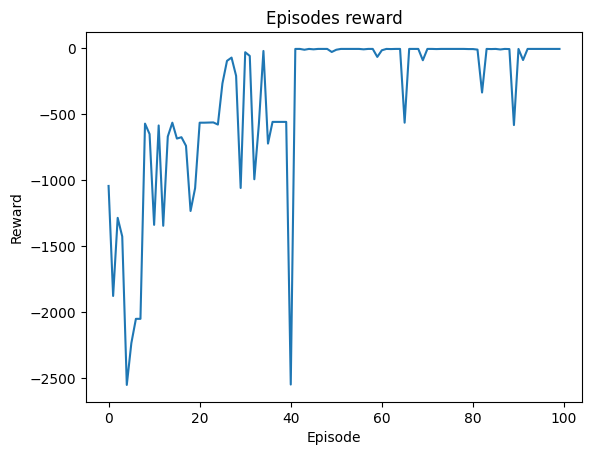

In [82]:
lineplot(data=episodes_rewards, title='Episodes reward', xlabel='Episode', ylabel='Reward')

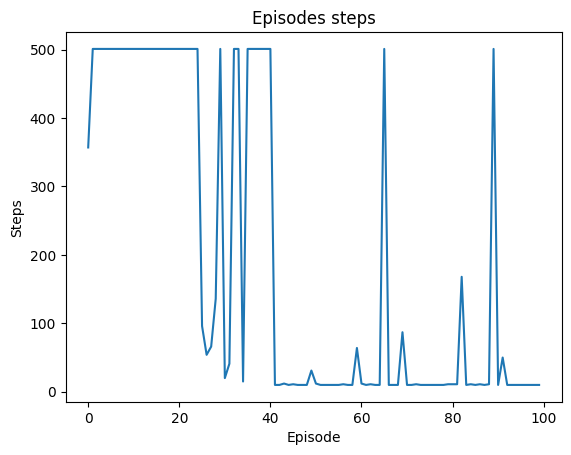

In [83]:
lineplot(data=episodes_steps, title='Episodes steps', xlabel='Episode', ylabel='Steps')

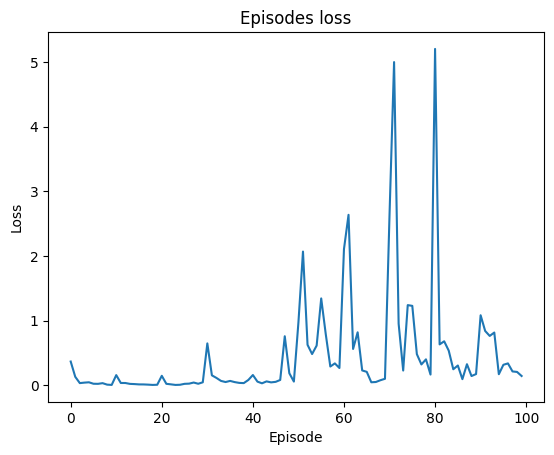

In [84]:
lineplot(data=episodes_loss, title='Episodes loss', xlabel='Episode', ylabel='Loss')

Streaming the policy after training is done:

In [85]:
stream_policy(env, policy)

video file name: video_1.mp4


Streaming the policy in mid-training:

In [86]:
stream_policy(env, mid_train_policy)

video file name: video_2.mp4


###  Default Environment Reward

Now, let's examine the default environment reward:

In [87]:
start_time = time.time()

env = EnvWrapper(sok, compliance=1, use_distance_reward=False)

mid_train_policy, policy, policy_net, done_count, episodes_steps, episodes_rewards, episodes_loss = dqn(env=env, num_episodes=100, batch_size=32, gamma=0.999, ep_decay=0.999, epsilon=1,
                                                                                                        target_freq_update=10, memory_buffer_size=10000, learning_rate=0.0001, steps_cutoff=500, 
                                                                                                        train_action_value_freq_update=1)
print(f'Training done. Total time: {time.time() - start_time} seconds.')

Running episode 1\100
Printing steps progress (up to 500 steps): 
1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95 96 97 98 99 100 101 102 103 104 105 106 107 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197 198 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215 216 217 218 219 220 221 222 223 224 225 226 227 228 229 230 231 232 233 234 235 236 237 238 239 240 241 242 243 244 245 246 247 248 249 250 251 252 253 254 255 256 257 258 259 260 26

Plotting training results

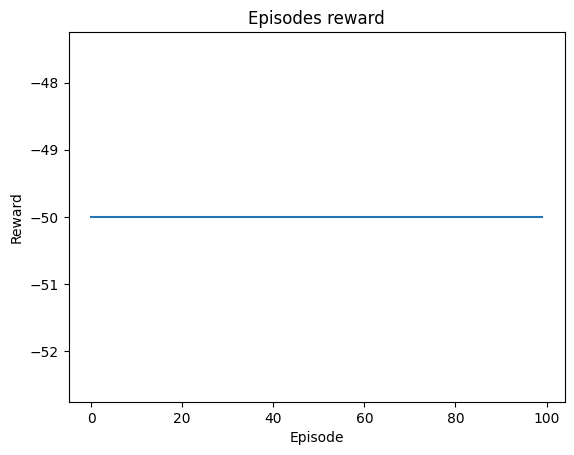

In [88]:
lineplot(data=episodes_rewards, title='Episodes reward', xlabel='Episode', ylabel='Reward')

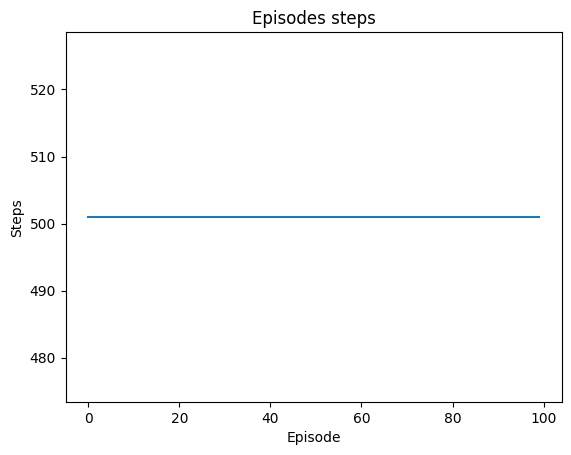

In [89]:
lineplot(data=episodes_steps, title='Episodes steps', xlabel='Episode', ylabel='Steps')

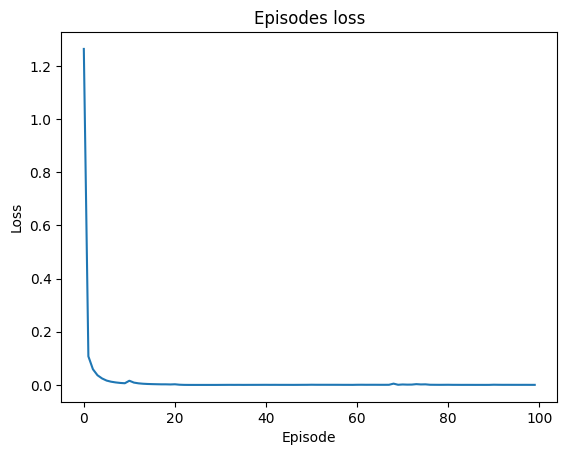

In [90]:
lineplot(data=episodes_loss, title='Episodes loss', xlabel='Episode', ylabel='Loss')

We can see that despite conducting the learning process correctly, as indicated by the converging loss graph, the intended objective was not reached: The reward and step graphs reveal that the agent's state remains unchanged, and it has not acquired the necessary policy knowledge.
One can easily see this by watching the accompanying policy videos:

Streaming the policy after training is done:

In [91]:
stream_policy(env, policy)

video file name: video_3.mp4


Streaming the policy in mid-training:

In [92]:
stream_policy(env, mid_train_policy)

video file name: video_4.mp4


## EX2 - PUSH & PULL - ONE BOX

In [93]:
#=============== DO NOT DELETE ===============
sok_2 = PushAndPullSokobanEnv(dim_room=(7, 7),num_boxes=1 ,max_steps=500)
# ============================================

In [94]:
start_time = time.time()

env = EnvWrapper(sok_2, compliance=1, use_distance_reward=True)

mid_train_policy, policy, policy_net, done_count, episodes_steps, episodes_rewards, episodes_loss = dqn(env=env, num_episodes=100, batch_size=32, gamma=0.999, ep_decay=0.999, epsilon=1,
                                                                                                        target_freq_update=10, memory_buffer_size=10000, learning_rate=0.0001, steps_cutoff=500, 
                                                                                                        train_action_value_freq_update=1)
print(f'Training done. Total time: {time.time() - start_time} seconds.')

Running episode 1\100
Printing steps progress (up to 500 steps): 
1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95 96 97 98 
Running episode 2\100
Printing steps progress (up to 500 steps): 
1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95 96 97 98 99 100 101 102 103 104 105 106 107 108 109 110 
Running episode 3\100
Printing steps progress (up to 500 steps): 
1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 
Running episode 4\100
Printing steps progress (up to 500 steps): 
1 2 3 4 5 6 7 8 9 10 11 12 13 14 15

Plotting training results

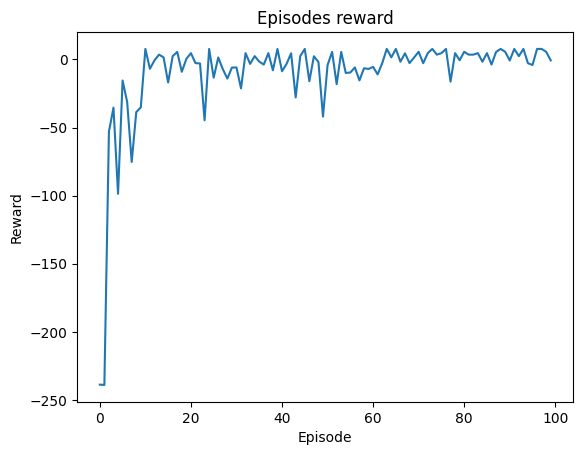

In [95]:
lineplot(data=episodes_rewards, title='Episodes reward', xlabel='Episode', ylabel='Reward')

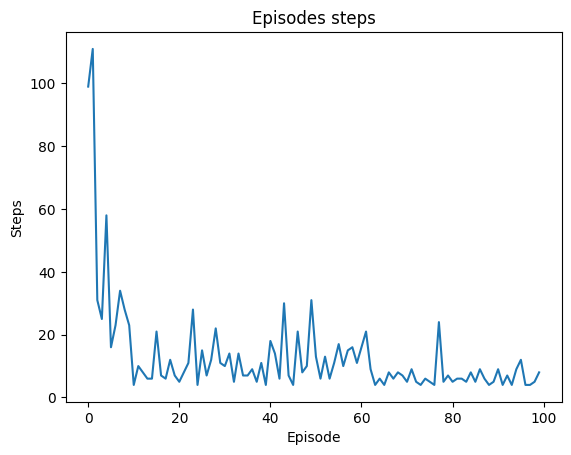

In [96]:
lineplot(data=episodes_steps, title='Episodes steps', xlabel='Episode', ylabel='Steps')

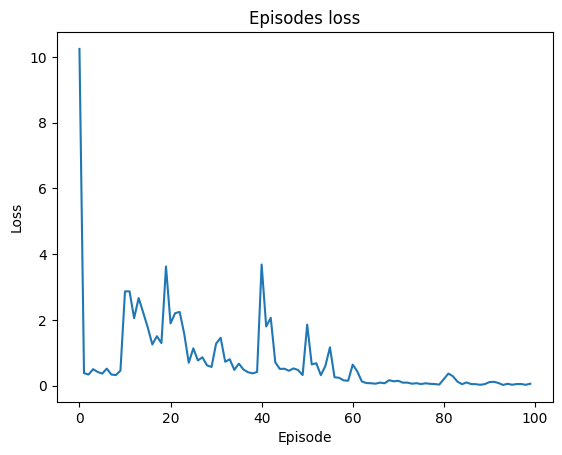

In [97]:
lineplot(data=episodes_loss, title='Episodes loss', xlabel='Episode', ylabel='Loss')

Streaming the policy after training is done:

In [98]:
stream_policy(env, policy)

video file name: video_5.mp4


Streaming the policy in mid-training:

In [99]:
stream_policy(env, mid_train_policy)

video file name: video_6.mp4


## EX3 - PUSH & PULL - TWO BOXES

In [100]:
#=============== DO NOT DELETE ===============
sok_3 = PushAndPullSokobanEnv(dim_room=(7, 7),num_boxes=2 ,max_steps=500)
# ============================================

In [101]:
start_time = time.time()

env = EnvWrapper(sok_3, compliance=1, use_distance_reward=True)

mid_train_policy, policy, policy_net, done_count, episodes_steps, episodes_rewards, episodes_loss = dqn(env=env, num_episodes=100, batch_size=32, gamma=0.999, ep_decay=0.999, epsilon=1,
                                                                                                        target_freq_update=10, memory_buffer_size=10000, learning_rate=0.0001, steps_cutoff=500, 
                                                                                                        train_action_value_freq_update=1)
print(f'Training done. Total time: {time.time() - start_time} seconds.')

Running episode 1\100
Printing steps progress (up to 500 steps): 
1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72 73 74 75 76 77 78 79 80 81 82 83 84 85 86 87 88 89 90 91 92 93 94 95 96 97 98 99 100 101 102 103 104 105 106 107 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197 198 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215 216 217 218 219 220 221 222 223 224 225 226 227 228 229 230 231 232 233 234 235 236 237 238 239 240 241 242 243 244 245 246 247 248 249 250 251 252 253 254 255 256 257 258 259 260 26

Plotting training results

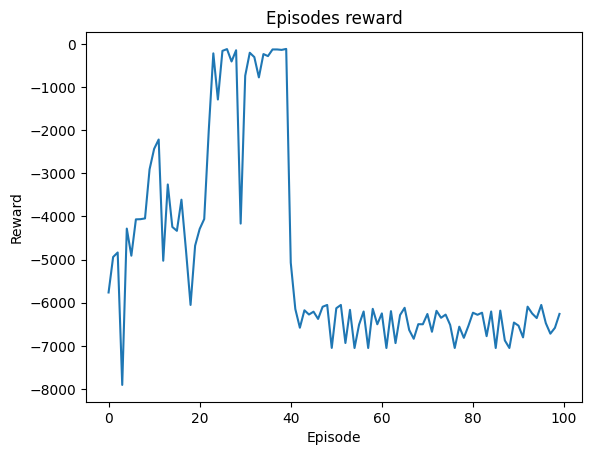

In [102]:
lineplot(data=episodes_rewards, title='Episodes reward', xlabel='Episode', ylabel='Reward')

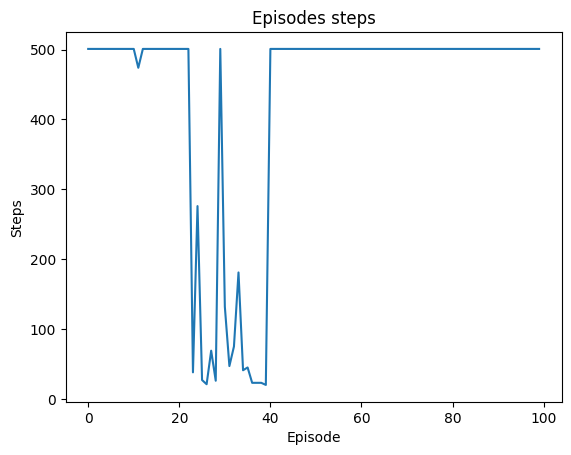

In [103]:
lineplot(data=episodes_steps, title='Episodes steps', xlabel='Episode', ylabel='Steps')

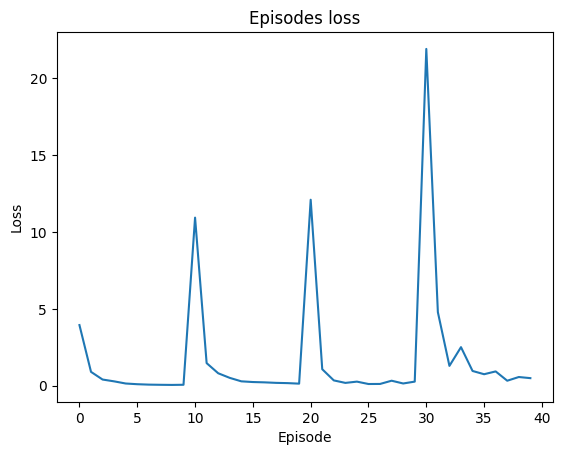

In [104]:
lineplot(data=episodes_loss, title='Episodes loss', xlabel='Episode', ylabel='Loss')

Streaming the policy after training is done:

In [105]:
stream_policy(env, policy)

video file name: video_7.mp4


Streaming the policy in mid-training:

In [106]:
stream_policy(env, mid_train_policy)

video file name: video_8.mp4
